![QuantConnect Logo](https://cdn.quantconnect.com/web/i/icon.png)
<hr>

## Quiver Government Contracts Research

This notebook studies whether government contract dollar volume helps explain future returns

In [1]:
qb = QuantBook()
# Daily bars will have an end_time that matches the following midnight.
qb.settings.daily_precise_end_time = False

### Build a Government Contract Universe

Select assets with frequent, sizable US government contracts, then inspect the returned universe history.

In [2]:
def select_assets(data: List[QuiverGovernmentContractUniverse]) -> List[Symbol]:
    # Group by ticker and keep names with 3+ contracts totalling over $50K.
    contracts_by_symbol: dict[Symbol, list[QuiverGovernmentContractUniverse]] = {}
    for d in data:
        contracts_by_symbol.setdefault(d.symbol, []).append(d)
    return [s for s, ds in contracts_by_symbol.items()
            if len(ds) >= 3 and sum(x.amount or 0 for x in ds) > 50_000]

# Add the Quiver Government Contract universe.
universe = qb.add_universe(QuiverGovernmentContractUniverse, select_assets)
# Request universe history of the last 120 days.
universe_history = qb.universe_history(universe, qb.time - timedelta(120), qb.time - timedelta(1), flatten=True)
# Print the returned shape and columns.
print(f"Shape: {universe_history.shape}")
print(f"Columns: {list(universe_history.columns)}")
universe_history.head()

Shape: (583, 5)
Columns: ['agency', 'amount', 'description', 'time', 'value']


agency    amount  \
time                                                                   
2026-02-03 EW RTKJ7O7ZTI79  Department of Veterans Affairs   32500.0   
           EW RTKJ7O7ZTI79  Department of Veterans Affairs   34000.0   
           EW RTKJ7O7ZTI79  Department of Veterans Affairs   34000.0   
           EW RTKJ7O7ZTI79  Department of Veterans Affairs  136000.0   
           EW RTKJ7O7ZTI79  Department of Veterans Affairs   34000.0   

                                         description       time     value  
time                                                                       
2026-02-03 EW RTKJ7O7ZTI79              AORTIC VALVE 2026-02-03   32500.0  
           EW RTKJ7O7ZTI79              AORTIC VALVE 2026-02-03   34000.0  
           EW RTKJ7O7ZTI79              AORTIC VLAVE 2026-02-03   34000.0  
           EW RTKJ7O7ZTI79  CUSTOM SURGICAL IMPLANTS 2026-02-03  136000.0  
           EW RTKJ7O7ZTI79          SURGICAL IMPLANT 2026-02-03   34000.0

### Universe Diagnostics

Inspects the raw contract amount distribution and visualizes how the daily universe size evolves chronologically.

Universe days: 101
Mean basket size per day: 2.8

count    5.830000e+02
mean     1.806813e+05
std      4.145566e+05
min      0.000000e+00
25%      3.645650e+04
50%      5.254690e+04
75%      2.288102e+05
max      9.000000e+06
Name: amount, dtype: float64


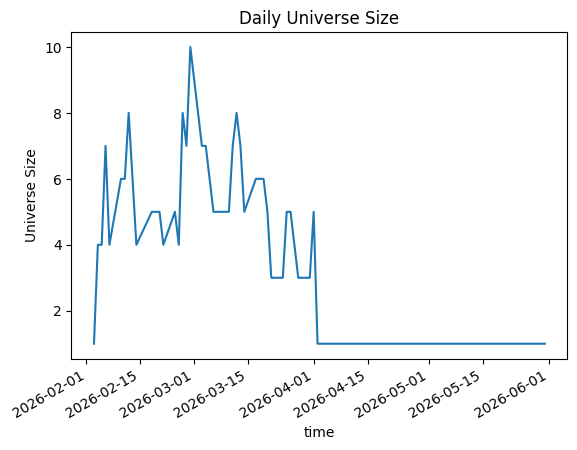

In [3]:
# Count selected assets by day.
universe_size = universe_history.groupby(level=[0, 1]).count().amount.groupby(level=0).count()
print(f"Universe days: {len(universe_size)}")
# Store the selected symbol list.
unique_assets = list(universe_history.index.levels[1].unique())
print(f"Mean basket size per day: {universe_size.mean():.1f}")
print('')
print(universe_history.amount.describe())
universe_size.plot(title='Daily Universe Size', ylabel='Universe Size');

### Daily Universe Prices

Fetch daily price history for every symbol that appears in the universe.

In [4]:
# Extract unique assets
symbols = list(universe_history.index.get_level_values(1).unique())
# Fetch daily historical price metrics using the earliest timestamp available in the index.
history = qb.history(symbols, universe_history.index[0][0] - timedelta(1), qb.time, Resolution.DAILY)
history

close     high      low    open     volume
symbol           time                                                   
EW RTKJ7O7ZTI79  2026-02-03   82.65   82.890   81.305   81.44  3778612.0
                 2026-02-04   82.10   83.770   82.000   82.38  3389435.0
                 2026-02-05   79.77   81.970   79.645   81.48  6115515.0
                 2026-02-06   78.10   80.650   77.465   79.87  6984869.0
                 2026-02-07   78.71   78.845   77.440   78.35  6475687.0
...                             ...      ...      ...     ...        ...
CAH R735QTJ8XC9X 2026-05-23  200.68  202.410  199.730  201.98  1323710.0
                 2026-05-27  200.37  201.430  199.480  200.00  1679645.0
                 2026-05-28  199.84  201.400  199.310  200.59  1403589.0
                 2026-05-29  199.85  201.790  197.635  199.54  1914690.0
                 2026-05-30  196.80  201.510  196.200  201.35  2693424.0

[2505 rows x 5 columns]

### Align Contract Volume And Returns

Build a joined table of contract dollar volume and future returns.

In [5]:
dataset = (
    universe_history.groupby(level=[0, 1]).agg(dollarvolume=('amount', 'sum')).rename_axis(['time', 'symbol'])
    .join(history.open.unstack('symbol').sort_index().pct_change(2, fill_method=None).shift(-2).stack().rename('futurereturn').rename_axis(['time','symbol']), how='inner')
)
dataset.head()

dollarvolume  futurereturn
time       symbol                                       
2026-02-03 EW RTKJ7O7ZTI79       270500.00      0.000491
2026-02-04 DNOW VR22RBI5MBFP        159.25      0.020526
           EW RTKJ7O7ZTI79        34000.00     -0.030469
           MCK R735QTJ8XC9X      500000.00      0.023437
           SYK R735QTJ8XC9X       28667.94     -0.013924

### Analyze Relationships Between Factor and Future Returns

Create a box plot of dollar-volume quantile buckets compared to future returns.

Factor: dollarvolume


,bucket,mean_factor,min_future_return,max_future_return,mean_future_return,std_future_return,observations
0,"(-0.001, 20310.492]",6348.423,-18.21%,10.21%,-0.20%,3.89%,52
1,"(20310.492, 36988.0]",33767.580,-9.29%,13.13%,0.11%,3.57%,51
2,"(36988.0, 46919.8]",42213.001,-7.16%,4.94%,-0.56%,2.46%,51
3,"(46919.8, 249631.0]",111902.568,-7.46%,13.65%,0.29%,4.09%,51
4,"(249631.0, 9000000.0]",1298926.058,-19.10%,7.30%,-0.41%,4.89%,52


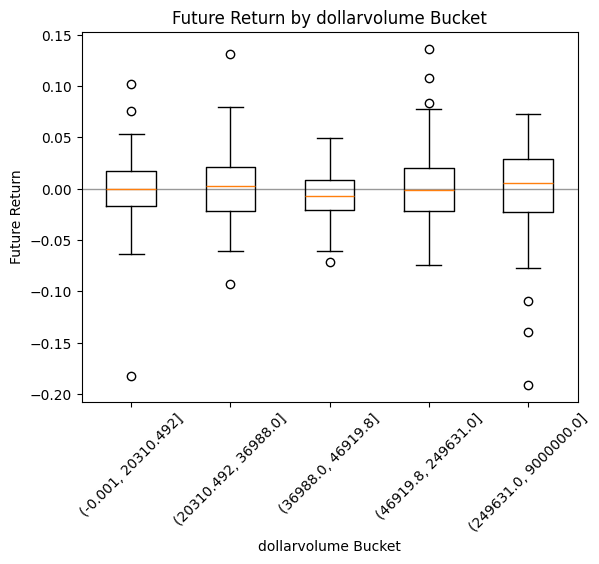

In [6]:
factor = 'dollarvolume'
# Split factor values into quantile buckets.
x = dataset[factor]
y = dataset['futurereturn']
buckets = pd.qcut(x, q=5, duplicates='drop')
# Summarize each bucket with distribution statistics.
summary = dataset.assign(bucket=buckets).groupby('bucket', observed=True).agg(
    mean_factor=(factor, 'mean'),
    min_future_return=('futurereturn', 'min'),
    max_future_return=('futurereturn', 'max'),
    mean_future_return=('futurereturn', 'mean'),
    std_future_return=('futurereturn', 'std'),
    observations=('futurereturn', 'size')
).reset_index()
summary['bucket'] = summary['bucket'].astype(str)
# Display the bucket summary.
print(f"Factor: {factor}")
display(summary.style.format({
    'mean_factor': '{:.3f}',
    'min_future_return': '{:.2%}',
    'max_future_return': '{:.2%}',
    'mean_future_return': '{:.2%}',
    'std_future_return': '{:.2%}'
}))
# Plot the return distribution for each bucket.
groups = [y[buckets == b].values for b in buckets.cat.categories]
plt.boxplot(groups, labels=[str(b) for b in buckets.cat.categories])
plt.axhline(0, color='black', linewidth=1, alpha=0.4)
plt.title(f'Future Return by {factor} Bucket')
plt.xlabel(f'{factor} Bucket')
plt.ylabel('Future Return')
plt.xticks(rotation=45)
plt.show()